# Modify dataset from Solar station site 8 (China)

In [41]:
import pandas as pd
root = '/home/brakine/VMD_STL_Parallel_TimesNet_BiLSTM_POWERFORECASTING/'
Dataset = pd.read_excel(root + 'data/dataset_figshare.xlsx').drop(index=0)
Dataset.to_csv(root + '/data/dataset_figshare.csv', index=False)
Dataset.head()

,Time(year-month-day h:m:s),Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Air temperature (°C),Atmosphere (hpa),Relative humidity (%),Power (MW)
1,2019-01-01 00:15:00,0.0,0.0,0.0,1.23,988.20,88.41,0.0
2,2019-01-01 00:30:00,0.0,0.0,0.0,1.44,921.90,83.10,0.0
3,2019-01-01 00:45:00,0.0,0.0,0.0,1.47,944.23,72.45,0.0
4,2019-01-01 01:00:00,0.0,0.0,0.0,1.70,1015.20,87.07,0.0
5,2019-01-01 01:15:00,0.0,0.0,0.0,1.73,958.73,85.49,0.0


In [42]:
Dataset["Time(year-month-day h:m:s)"] = pd.to_datetime(Dataset["Time(year-month-day h:m:s)"])
Dataset = Dataset.sort_values("Time(year-month-day h:m:s)").set_index("Time(year-month-day h:m:s)")
Dataset.head()

,Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Air temperature (°C),Atmosphere (hpa),Relative humidity (%),Power (MW)
Time(year-month-day h:m:s),,,,,,,
2019-01-01 00:15:00,0.0,0.0,0.0,1.23,988.20,88.41,0.0
2019-01-01 00:30:00,0.0,0.0,0.0,1.44,921.90,83.10,0.0
2019-01-01 00:45:00,0.0,0.0,0.0,1.47,944.23,72.45,0.0
2019-01-01 01:00:00,0.0,0.0,0.0,1.70,1015.20,87.07,0.0
2019-01-01 01:15:00,0.0,0.0,0.0,1.73,958.73,85.49,0.0


In [44]:
Dataset.describe().round(2)

,Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Air temperature (°C),Atmosphere (hpa),Relative humidity (%),Power (MW)
count,69407.00,69407.00,69407.00,69407.00,69407.00,69407.00,69407.00
mean,163.25,142.02,21.22,18.01,956.42,71.71,4.23
std,245.40,213.49,31.90,8.56,30.54,18.50,6.52
min,0.00,0.00,0.00,-8.04,881.40,11.83,0.00
25%,0.00,0.00,0.00,11.37,932.30,59.27,0.00
50%,0.00,0.00,0.00,18.19,956.07,73.53,0.00
75%,271.05,235.82,35.24,24.25,980.09,85.99,6.44
max,1214.54,1056.65,157.89,47.63,1037.78,100.00,29.41


## Masking day values

In [45]:
# use DatetimeIndex.hour to get hour values from the index
idx_hour = Dataset.index.hour
mask = (idx_hour >= 7) & (idx_hour < 19)
day_dataset = Dataset[mask]
day_dataset

,Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Air temperature (°C),Atmosphere (hpa),Relative humidity (%),Power (MW)
Time(year-month-day h:m:s),,,,,,,
2019-01-01 07:00:00,0.00,0.00,0.00,3.330000,944.600000,67.250000,0.00
2019-01-01 07:15:00,0.00,0.00,0.00,2.900000,961.920000,73.560000,0.00
2019-01-01 07:30:00,10.29,8.95,1.34,3.210000,979.790000,67.560000,0.41
2019-01-01 07:45:00,18.04,15.69,2.34,3.260000,1012.460000,76.130000,0.69
2019-01-01 08:00:00,28.92,25.16,3.76,3.220000,960.370000,70.510000,1.17
...,...,...,...,...,...,...,...
2020-12-31 17:45:00,0.00,0.00,0.00,1.341829,989.488130,29.743798,0.00
2020-12-31 18:00:00,0.00,0.00,0.00,1.041539,974.819201,32.465638,0.00
2020-12-31 18:15:00,0.00,0.00,0.00,0.845621,941.468064,31.761107,0.00


In [46]:
day_dataset.describe().round(2)

,Total solar irradiance (W/m2),Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Air temperature (°C),Atmosphere (hpa),Relative humidity (%),Power (MW)
count,34704.00,34704.00,34704.00,34704.00,34704.00,34704.00,34704.00
mean,324.68,282.47,42.21,20.81,956.40,63.07,8.42
std,261.16,227.21,33.95,8.35,30.54,18.93,7.06
min,0.00,0.00,0.00,-5.66,881.56,11.83,0.00
25%,99.23,86.33,12.90,14.42,932.13,48.75,2.46
50%,271.05,235.82,35.24,21.07,956.09,62.69,6.44
75%,519.48,451.95,67.53,26.89,980.23,76.91,13.82
max,1214.54,1056.65,157.89,47.63,1037.44,100.00,29.41


## Checking null-values existence

In [47]:
day_dataset.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34704 entries, 2019-01-01 07:00:00 to 2020-12-31 18:45:00
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Total solar irradiance (W/m2)        34704 non-null  float64
 1   Direct normal irradiance (W/m2)      34704 non-null  float64
 2   Global horizontal irradiance (W/m2)  34704 non-null  float64
 3   Air temperature  (°C)                34704 non-null  float64
 4   Atmosphere (hpa)                     34704 non-null  float64
 5   Relative humidity (%)                34704 non-null  float64
 6   Power (MW)                           34704 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


## View correlation matrix

<Axes: >

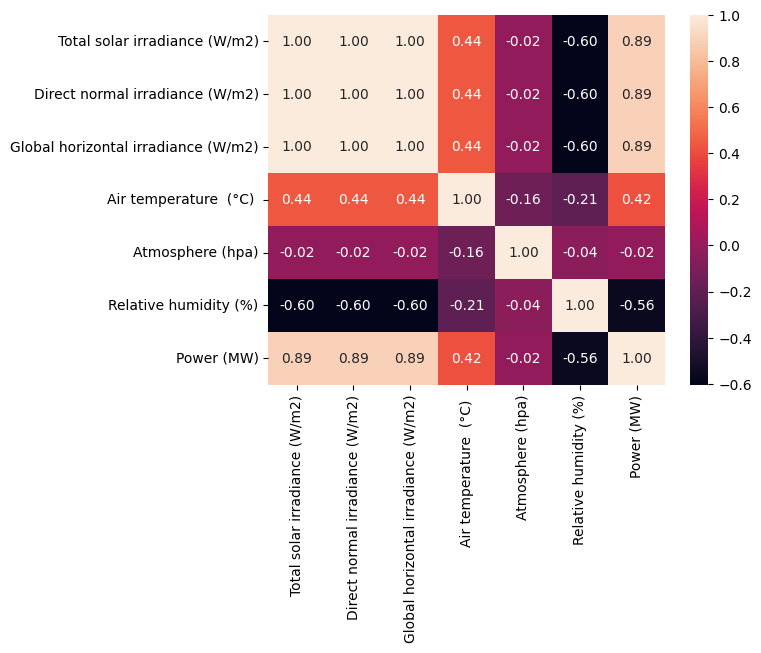

In [49]:
import seaborn as sns
corr_1 = Dataset.corr() 
sns.heatmap(corr_1, annot=True, fmt=".2f")

<Axes: >

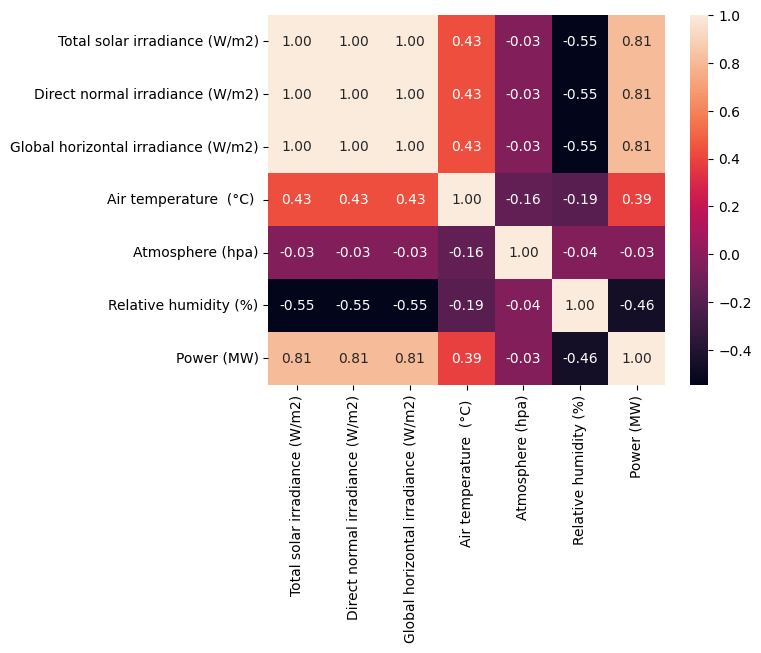

In [50]:
corr = day_dataset.corr() 
sns.heatmap(corr, annot=True, fmt=".2f")

## Keep only Total solar irradancie

In [55]:
# Drop columns using the correct column names (note the space before '(').
# use errors='ignore' so dropping non-existing columns doesn't raise KeyError
day_dataset.drop(columns=['Global horizontal irradiance (W/m2)',
                    'Direct normal irradiance (W/m2)',
                    'Atmosphere (hpa)'], inplace=True, errors='ignore')
day_dataset.head()

,Total solar irradiance (W/m2),Air temperature (°C),Relative humidity (%),Power (MW)
Time(year-month-day h:m:s),,,,
2019-01-01 07:00:00,0.00,3.33,67.25,0.00
2019-01-01 07:15:00,0.00,2.90,73.56,0.00
2019-01-01 07:30:00,10.29,3.21,67.56,0.41
2019-01-01 07:45:00,18.04,3.26,76.13,0.69
2019-01-01 08:00:00,28.92,3.22,70.51,1.17


In [56]:
day_dataset.describe().round(2)

,Total solar irradiance (W/m2),Air temperature (°C),Relative humidity (%),Power (MW)
count,34704.00,34704.00,34704.00,34704.00
mean,324.68,20.81,63.07,8.42
std,261.16,8.35,18.93,7.06
min,0.00,-5.66,11.83,0.00
25%,99.23,14.42,48.75,2.46
50%,271.05,21.07,62.69,6.44
75%,519.48,26.89,76.91,13.82
max,1214.54,47.63,100.00,29.41


## Save final processed version

In [57]:
day_dataset.to_csv(root + '/data/dataset_figshare_processed.csv', index=True)